# Classificatore Real+Synthetic - RAD-DINO (foundation medico) con Fine-Tuning

Equivalente del notebook `14_Classificatore_RealSynthetic_MaxViT512_FineTuned.ipynb` con backbone **RAD-DINO** (Microsoft, ViT-B/14 pre-addestrato su radiografie/mammografie).

Configurazione dataset (identica ai classificatori MaxViT su Real+Synth):

- reali del training set + sintetici filtrati generati da Stable Diffusion 2.1 fine-tuned (`data/synthetic/fine_tuned/`);
- rapporto atteso ~55% negativi / 45% positivi (leggermente sbilanciato in favore della classe positiva);
- **stessa** logica di split e soglia Youden dei notebook MaxViT (13/14/17).

Serve a completare D2c estendendo il confronto MaxViT vs RAD-DINO anche alla configurazione Real+Synth, non solo alla baseline sui soli reali.

Cartella esperimento: `experiments/classifiers/raddino/04b_real_synth/`.

In [ ]:
# === Bootstrap unificato notebooks/ ===
# Funziona dalla root del progetto e da ogni sottocartella della struttura notebooks/.
import sys as _sys
from pathlib import Path as _Path


def _find_mammo_root():
    for _candidate in [_Path.cwd().resolve(), *_Path.cwd().resolve().parents]:
        if _candidate.name == "MammoDiffusion":
            return _candidate
        if (_candidate / "data").is_dir() and (_candidate / "notebooks").is_dir():
            return _candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata da " + str(_Path.cwd()))


PROJECT_ROOT = _find_mammo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
UTILITY_DIR = NOTEBOOKS_DIR / "utility"
for _path in (str(UTILITY_DIR), str(NOTEBOOKS_DIR)):
    if _path not in _sys.path:
        _sys.path.insert(0, _path)

BASE = PROJECT_ROOT
BASE_DIR = PROJECT_ROOT
BASE_PATH = str(PROJECT_ROOT) + "/"
# === Fine bootstrap unificato ===

import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"



In [2]:
import tensorflow as tf
from tensorflow.python.client import device_lib

print(tf.config.list_physical_devices("GPU"))

for d in device_lib.list_local_devices():
    if d.device_type == "GPU":
        print(d.physical_device_desc)

2026-07-06 11:20:37.927011: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-06 11:20:37.927044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-06 11:20:37.927998: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-06 11:20:37.933165: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-06 11:20:38.573765: W tensorflow/compiler/tf2

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:04:00.0, compute capability: 8.6


2026-07-06 11:20:39.623014: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-06 11:20:39.684619: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-06 11:20:39.698608: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:
import sys

# [notebooks bootstrap] Il blocco Colab/local originale e' stato
# neutralizzato: BASE_PATH e' gia' definito dal bootstrap unificato in cima.
print('Percorso base:', BASE_PATH)

Ambiente locale rilevato.
Percorso base: ../


In [4]:
import json
import zipfile
from datetime import date
from glob import glob

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)

sys.path.insert(0, os.getcwd())
from medfoundation_utils import (
    DEFAULT_MODEL_NAME, DEFAULT_IMG_SIZE,
    build_medfoundation_model, resolve_normalization_medfoundation,
    make_medfoundation_dataloader,
    freeze_backbone_all, unfreeze_head, unfreeze_last_n_blocks,
    count_trainable_params,
    BinaryFocalLoss, compute_pos_weight,
    EarlyStopping, ModelCheckpoint, CSVLogger, fit,
    predict_probs, optimal_threshold_youden,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


#### Preparazione dataset reale + sintetico fine-tuned

In [5]:
PROCESSED_DRIVE_ID = '1qQral_BIBlMl0QN3PllJukdYTOmNGWr3'
SYNTH_FINETUNED_DRIVE_ID = None  # se hai un ID Drive dedicato, mettilo qui; altrimenti il notebook si aspetta la cartella locale

TRAIN_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'train.csv')
VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'val.csv')
SYNTH_DIR = os.path.join(BASE_PATH, 'data', 'synthetic', 'fine_tuned')


def processed_data_ready():
    if not (os.path.isfile(TRAIN_CSV_PATH) and os.path.isfile(VAL_CSV_PATH)):
        return False
    try:
        first_path = pd.read_csv(TRAIN_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(os.path.join(BASE_PATH, first_path))
    except Exception:
        return False


if not processed_data_ready():
    PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)

df_train_real = pd.read_csv(TRAIN_CSV_PATH).reset_index(drop=True)
df_val = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)

def fix_path(p):
    if os.path.isabs(p) or p.startswith('../') or p.startswith('./'):
        return p
    return os.path.join(BASE_PATH, p)

df_train_real['processed_path'] = df_train_real['processed_path'].apply(fix_path)
df_val['processed_path'] = df_val['processed_path'].apply(fix_path)

synth_pos = sorted(glob(os.path.join(SYNTH_DIR, 'positive', '*.png')))
synth_neg = sorted(glob(os.path.join(SYNTH_DIR, 'negative', '*.png')))
if not synth_pos or not synth_neg:
    raise FileNotFoundError(
        f"Cartella sintetiche fine-tuned incompleta: {SYNTH_DIR}. "
        "Esegui prima 02_SD21_Filtered_100steps.ipynb, o scarica il dataset dal Drive."
    )

df_synth = pd.DataFrame({
    'processed_path': synth_pos + synth_neg,
    'cancer': [1] * len(synth_pos) + [0] * len(synth_neg),
    'source': ['synthetic'] * (len(synth_pos) + len(synth_neg)),
})
if 'source' not in df_train_real.columns:
    df_train_real['source'] = 'real'

df_train = pd.concat([df_train_real, df_synth], ignore_index=True)
print(f"Reali train: {len(df_train_real)} | Sintetici: {len(df_synth)} (pos {len(synth_pos)}, neg {len(synth_neg)})")
print(f"Train combinato: {len(df_train)} | Distribuzione cancer:\n{df_train['cancer'].value_counts()}")

Reali train: 2041 | Sintetici: 2722 (pos 1361, neg 1361)
Train combinato: 4763 | Distribuzione cancer:
cancer
0    3062
1    1701
Name: count, dtype: int64


#### Configurazione, modello, dataloader

In [6]:
MODEL_NAME = DEFAULT_MODEL_NAME
IMG_SIZE = DEFAULT_IMG_SIZE
BATCH_SIZE = 4
SEED = 42

torch.manual_seed(SEED); np.random.seed(SEED)

OUTPUT_DIR = os.path.join(BASE_PATH, 'experiments', 'classifiers/raddino/04b_real_synth')
os.makedirs(OUTPUT_DIR, exist_ok=True)
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

model, image_processor, hidden_size = build_medfoundation_model(model_name=MODEL_NAME, num_classes=1)
resolved_mean, resolved_std, _ = resolve_normalization_medfoundation(image_processor)
model.to(DEVICE)

train_loader = make_medfoundation_dataloader(
    df_train, 'processed_path', 'cancer',
    resolved_mean, resolved_std, IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=True, augment=False, seed=SEED,
)
val_loader = make_medfoundation_dataloader(
    df_val, 'processed_path', 'cancer',
    resolved_mean, resolved_std, IMG_SIZE,
    batch_size=BATCH_SIZE, shuffle=False,
)

experiment_config = {
    'experiment_name': os.path.basename(OUTPUT_DIR),
    'date': date.today().isoformat(),
    'backbone': {
        'name': MODEL_NAME,
        'input_shape': [IMG_SIZE, IMG_SIZE, 3],
        'hidden_size': hidden_size,
    },
    'data': {
        'batch_size': BATCH_SIZE, 'seed': SEED,
        'n_real_train': int(len(df_train_real)),
        'n_synth_pos': int(len(synth_pos)),
        'n_synth_neg': int(len(synth_neg)),
        'train_csv': TRAIN_CSV_PATH, 'val_csv': VAL_CSV_PATH,
        'synth_dir': SYNTH_DIR,
    },
    'phase1_head_training': {
        'optimizer': 'Adam', 'learning_rate': 1e-3,
        'loss': 'BCEWithLogitsLoss(pos_weight=balanced)',
        'max_epochs': 25, 'early_stopping_patience': 7,
    },
    'phase2_fine_tuning': {
        'optimizer': 'Adam', 'learning_rate': 1e-5,
        'loss': 'BinaryFocalLoss(alpha=0.75, gamma=2.0)',
        'max_epochs': 30, 'unfreeze': 'ultimi 2 block ViT + layernorm',
        'early_stopping_patience': 5, 'early_stopping_min_delta': 1e-3,
        'reduce_lr_factor': 0.5, 'reduce_lr_patience': 3, 'min_lr': 1e-7,
    },
}
with open(os.path.join(OUTPUT_DIR, 'experiment_config.json'), 'w') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)
print('Config salvata in:', os.path.join(OUTPUT_DIR, 'experiment_config.json'))

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Config salvata in: ../experiments/exp_raddino_real_synth_partial/experiment_config.json


In [7]:
freeze_backbone_all(model); unfreeze_head(model)
trainable, total = count_trainable_params(model)
print(f"Parametri trainable (Fase 1): {trainable:,} / {total:,}")

pos_weight = compute_pos_weight(df_train['cancer'].values).to(DEVICE)
criterion_fase1 = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_fase1 = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-3,
)

early_stop_fase1 = EarlyStopping(patience=7, mode='max', restore_best_weights=True)
checkpoint_fase1 = ModelCheckpoint(os.path.join(OUTPUT_DIR, 'real_synth_raddino_fase1_best.pt'), mode='max')
csv_logger_fase1 = CSVLogger(os.path.join(OUTPUT_DIR, 'training_log_fase1.csv'))

history_phase1 = fit(
    model, train_loader, val_loader, optimizer_fase1, criterion_fase1,
    epochs=25, device=DEVICE,
    early_stopping=early_stop_fase1, checkpoint=checkpoint_fase1, csv_logger=csv_logger_fase1,
)

Parametri trainable (Fase 1): 769 / 86,581,249
Epoch 1/25 - loss: 0.7797 - auc: 0.7357 - val_loss: 0.6761 - val_auc: 0.5451
Epoch 2/25 - loss: 0.7226 - auc: 0.7843 - val_loss: 0.6848 - val_auc: 0.5544
Epoch 3/25 - loss: 0.7124 - auc: 0.7907 - val_loss: 0.6827 - val_auc: 0.5613
Epoch 4/25 - loss: 0.6933 - auc: 0.8060 - val_loss: 0.6790 - val_auc: 0.5601
Epoch 5/25 - loss: 0.6904 - auc: 0.8074 - val_loss: 0.6746 - val_auc: 0.5708
Epoch 6/25 - loss: 0.6869 - auc: 0.8101 - val_loss: 0.7264 - val_auc: 0.5659
Epoch 7/25 - loss: 0.6815 - auc: 0.8136 - val_loss: 0.6863 - val_auc: 0.5785
Epoch 8/25 - loss: 0.6774 - auc: 0.8161 - val_loss: 0.7037 - val_auc: 0.5738
Epoch 9/25 - loss: 0.6739 - auc: 0.8192 - val_loss: 0.7035 - val_auc: 0.5765
Epoch 10/25 - loss: 0.6669 - auc: 0.8223 - val_loss: 0.6949 - val_auc: 0.5742
Epoch 11/25 - loss: 0.6673 - auc: 0.8228 - val_loss: 0.7054 - val_auc: 0.5749
Epoch 12/25 - loss: 0.6686 - auc: 0.8214 - val_loss: 0.6995 - val_auc: 0.5782
Epoch 13/25 - loss: 0.6766

In [8]:
unfreeze_last_n_blocks(model, n=2)
trainable, total = count_trainable_params(model)
print(f"Parametri trainable (Fase 2): {trainable:,} / {total:,}")

criterion_fase2 = BinaryFocalLoss(alpha=0.75, gamma=2.0)
optimizer_fase2 = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-5,
)
lr_scheduler_fase2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fase2, mode='max', factor=0.5, patience=3, min_lr=1e-7,
)
early_stop_fase2 = EarlyStopping(patience=5, min_delta=1e-3, mode='max', restore_best_weights=True)
checkpoint_fase2 = ModelCheckpoint(os.path.join(OUTPUT_DIR, 'real_synth_raddino_final_best.pt'), mode='max')
csv_logger_fase2 = CSVLogger(os.path.join(OUTPUT_DIR, 'training_log_fase2.csv'))

history_phase2 = fit(
    model, train_loader, val_loader, optimizer_fase2, criterion_fase2,
    epochs=30, device=DEVICE,
    early_stopping=early_stop_fase2, checkpoint=checkpoint_fase2, csv_logger=csv_logger_fase2,
    lr_scheduler=lr_scheduler_fase2,
)
print('\nBest model salvato in:', os.path.join(OUTPUT_DIR, 'real_synth_raddino_final_best.pt'))

Parametri trainable (Fase 2): 14,181,121 / 86,581,249
Epoch 1/30 - loss: 0.0619 - auc: 0.8157 - val_loss: 0.0683 - val_auc: 0.5825
Epoch 2/30 - loss: 0.0540 - auc: 0.8359 - val_loss: 0.0625 - val_auc: 0.5812
Epoch 3/30 - loss: 0.0521 - auc: 0.8446 - val_loss: 0.0609 - val_auc: 0.5959
Epoch 4/30 - loss: 0.0483 - auc: 0.8671 - val_loss: 0.0626 - val_auc: 0.5863
Epoch 5/30 - loss: 0.0457 - auc: 0.8837 - val_loss: 0.0641 - val_auc: 0.5907
Epoch 6/30 - loss: 0.0411 - auc: 0.9076 - val_loss: 0.0671 - val_auc: 0.5908
Epoch 7/30 - loss: 0.0360 - auc: 0.9307 - val_loss: 0.0746 - val_auc: 0.5896
Epoch 8/30 - loss: 0.0281 - auc: 0.9611 - val_loss: 0.0875 - val_auc: 0.5743
Early stopping all'epoca 8 (best val_auc=0.5959)

Best model salvato in: ../experiments/exp_raddino_real_synth_partial/real_synth_raddino_final_best.pt


AUC: 0.5959
Soglia ottimale: 0.454

              precision    recall  f1-score   support

   No cancro       0.89      0.49      0.63       364
      Cancro       0.21      0.68      0.33        73

    accuracy                           0.53       437
   macro avg       0.55      0.59      0.48       437
weighted avg       0.77      0.53      0.58       437



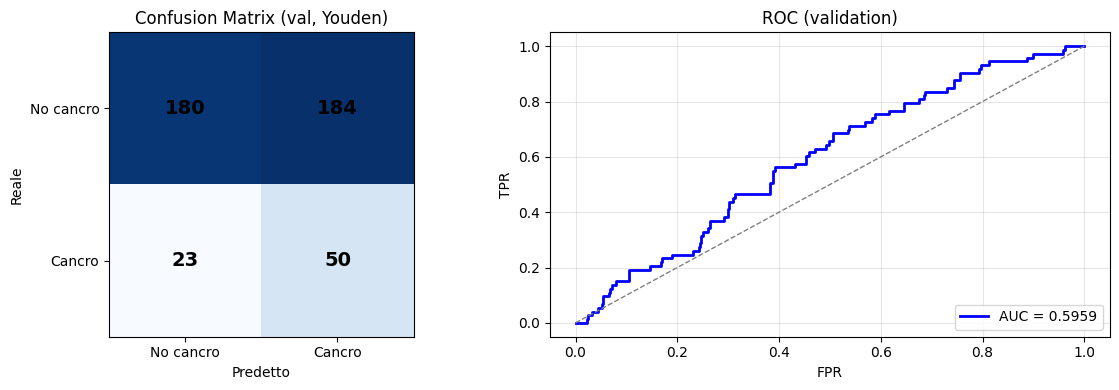

Metriche salvate in: ../experiments/exp_raddino_real_synth_partial/val_metrics.json


In [9]:
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, 'real_synth_raddino_final_best.pt'), map_location=DEVICE))
y_true, y_pred_prob = predict_probs(model, val_loader, DEVICE)
best_threshold = optimal_threshold_youden(y_true, y_pred_prob)
y_pred = (y_pred_prob >= best_threshold).astype(int)

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
val_auc = roc_auc_score(y_true, y_pred_prob)
report_str = classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro'])
print(f'AUC: {val_auc:.4f}\nSoglia ottimale: {best_threshold:.3f}\n\n{report_str}')

metrics_dict = {
    'split': 'validation',
    'backbone': MODEL_NAME,
    'experiment_name': os.path.basename(OUTPUT_DIR),
    'auc': round(float(val_auc), 4),
    'optimal_threshold_youden': round(float(best_threshold), 4),
    'accuracy': round(float((y_pred == y_true).mean()), 4),
    'precision_cancer': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'recall_cancer':    round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'f1_cancer':        round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report_str,
}
with open(os.path.join(OUTPUT_DIR, 'val_metrics.json'), 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)

cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No cancro', 'Cancro'])
axes[0].set_yticklabels(['No cancro', 'Cancro'])
axes[0].set_xlabel('Predetto'); axes[0].set_ylabel('Reale')
axes[0].set_title('Confusion Matrix (val, Youden)')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')
axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {val_auc:.4f}')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[1].set(xlabel='FPR', ylabel='TPR', title='ROC (validation)')
axes[1].legend(loc='lower right'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'val_confusion_roc.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Metriche salvate in:', os.path.join(OUTPUT_DIR, 'val_metrics.json'))